# Query Shape File for High Quality Satellite Date on Large Fires

This script uses the Monitoring Trends in Burn Severity (MTBS) shape file to instanteonously grab the dates and bounding box coordinates for large fires in Alaska and the Westernmost states in the contintental United States (Washington, Oregon, and Califoria). It then uses the SpatioTemporal Asset Catalog (STAC) API to instantly retrieve Sentinel-1, Sentinel-2, and ERA-5 data that all intersect with the provided time and location of each fire.  

### Setup shape file by specifying dates and bounding box coordinates

In [2]:
import warnings
import re
import os
import geopandas as gpd 
from datetime import timedelta
from dotenv import load_dotenv

load_dotenv()
warnings.filterwarnings("ignore", category=UserWarning, message="Geometry is in a geographic CRS")

Retrieve the shape file and grab only fires that happened from 2016 to present.

In [3]:
# fetch the shape file (either MTBS or AKS)
shapefile_path = '/Users/asankoh/WildfirePrediction/MTBS/S_USA.MTBS_BURN_AREA_BOUNDARY/S_USA.MTBS_BURN_AREA_BOUNDARY.shp'
print("Loading MTBS Shapefile...")
gdf = gpd.read_file(shapefile_path)

# convert ignition date to standard date time format 
gdf['IG_DATE'] = gpd.pd.to_datetime(gdf['IG_DATE'], format='%Y%m%d')

# screen out pre-2016 fires (Sentinel-2 went online around June 2015)
gdf = gdf[gdf['IG_DATE'].dt.year >= 2016].copy()
print(f"Loaded {len(gdf)} fires from 2016-present.")

Loading MTBS Shapefile...
Loaded 8562 fires from 2016-present.


Create the bounding boxes for Alaska and the Western US using the standard coordinate system ($EPSG:4326$).

In [4]:
# reproject coordinates to standard lat/long
gdf_wgs84= gdf.to_crs(epsg=4326)

# grab the bounding box for Alaska (AK)
alaska_fires = gdf_wgs84[
    (gdf_wgs84.geometry.centroid.x  >= -170) & (gdf_wgs84.geometry.centroid.x  <= -140) &
    (gdf_wgs84.geometry.centroid.y  >= 52) & (gdf_wgs84.geometry.centroid.y <= 72)
]
# grab the bounding box for Western US (CA, OR, WA)
western_us_fires = gdf_wgs84[
    (gdf_wgs84.geometry.centroid.x   >= -125) & (gdf_wgs84.geometry.centroid.x   <= -114) &
    (gdf_wgs84.geometry.centroid.y >= 32) & (gdf_wgs84.geometry.centroid.y <= 49)
]

print(f"Found {len(alaska_fires)} large fires in Alaska and {len(western_us_fires)} large fires in the West Coast.")

Found 368 large fires in Alaska and 1373 large fires in the West Coast.


### Select a specific fire to query [START HERE]
This below cell is for Western US fires.

In [5]:
western_us_fires_filtered = western_us_fires[
    (western_us_fires['ACRES'] >= 50000) &
    (western_us_fires['ACRES'] <= 600000)
].sort_values(by='ACRES', ascending=False).copy()

print(f"Found {len(western_us_fires_filtered)} fires in 60k-600k acre range.")

Found 119 fires in 60k-600k acre range.


In [6]:
# query fire by acreage 
fire_index = 6
fire_scene = western_us_fires_filtered.iloc[fire_index]

# extract key attributes 
fire_name = fire_scene['FIRE_NAME']
ignition_date = fire_scene['IG_DATE']
fire_id_string = str(fire_scene['FIRE_ID'])
post_id_string = str(fire_scene['POST_ID'])
bounds = fire_scene.geometry.bounds
stac_boundary_box = [bounds[0], bounds[1], bounds[2], bounds[3]]

# Pre-fire scene window is 20 days leading up to the ignition date
pre_window = f"{(ignition_date - timedelta(days=20)).strftime('%Y-%m-%d')}/{(ignition_date - timedelta(days=1)).strftime('%Y-%m-%d')}"

# Post-fire scene window is 20 days around the 'optimal' post fire scene date ID
date_match = re.search(r'(20\d{6})\b', post_id_string)
if date_match:
    optimal_post_date = gpd.pd.to_datetime(date_match.group(1), format='%Y%m%d')
    post_start = optimal_post_date - timedelta(days=10)
    post_end = optimal_post_date + timedelta(days=10)
    post_window = f"{post_start.strftime('%Y-%m-%d')}/{post_end.strftime('%Y-%m-%d')}"

else:
    raise ValueError("No ideal post fire scene ID found. Consider querying another fire to maintain high scene quality.")

print(f"Isolated: {fire_scene['FIRE_NAME']} ({fire_scene['ACRES']:,} Acres)")
print(f"Boundary Box: {stac_boundary_box}")
print(f"Pre-Fire Search Window: {pre_window}")
print(f"Post-Fire Search Window: {post_window}")


Isolated: HENNESSEY (314,015.0 Acres)
Boundary Box: [-122.57983663452745, 38.295143280873795, -121.98546948013013, 38.95108046664877]
Pre-Fire Search Window: 2020-07-28/2020-08-16
Post-Fire Search Window: 2021-07-01/2021-07-21


### Call the STAC API to retrieve fire scene artifacts

In [7]:
import pystac_client 
import planetary_computer
import pandas as pd

Query for all clean Sentinel-2 scenes that fall within the two windows.

In [8]:
# connect to the microsoft planetary computer catelog 
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace
)

# query Sentinel-2 for the pre-fire window
print("Searching for pre-fire Sentinel-2 scene...")
pre_s2_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=stac_boundary_box,
    datetime=pre_window,
    query={"eo:cloud_cover": {"lt": 15}}
)
pre_s2_items = pre_s2_search.item_collection()
print(f"Found {len(pre_s2_items)} clean pre-fire Sentinel-2 scenes.")

# query Sentinel-2 for the post-fire window
print("Searching for post-fire Sentinel-2 scene...")
post_s2_search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=stac_boundary_box,
    datetime=post_window,
    query={"eo:cloud_cover": {"lt": 15}}
)
post_s2_items = post_s2_search.item_collection()
print(f"Found {len(post_s2_items)} clean post-fire Sentinel-2 scenes.")



Searching for pre-fire Sentinel-2 scene...
Found 16 clean pre-fire Sentinel-2 scenes.
Searching for post-fire Sentinel-2 scene...
Found 16 clean post-fire Sentinel-2 scenes.


Query for all Sentinel-1 scenes that fall within the two windows.

In [9]:
# query Sentinel-1 for the pre-fire window
print("Searching for pre-fire Sentinel-1 scene...")
pre_s1_search = catalog.search(
    collections=["sentinel-1-grd"],
    bbox=stac_boundary_box,
    datetime=pre_window,
)
pre_s1_items = pre_s1_search.item_collection()
print(f"Found {len(pre_s1_items)} pre-fire Sentinel-1 scenes.")

# query Sentinel-1 for the post-fire window
print("Searching for post-fire Sentinel-1 scene...")
post_s1_search = catalog.search(
    collections=["sentinel-1-grd"],
    bbox=stac_boundary_box,
    datetime=post_window,
)
post_s1_items = post_s1_search.item_collection()
print(f"Found {len(post_s1_items)} post-fire Sentinel-1 scenes.")

Searching for pre-fire Sentinel-1 scene...
Found 14 pre-fire Sentinel-1 scenes.
Searching for post-fire Sentinel-1 scene...
Found 18 post-fire Sentinel-1 scenes.


Find all pairs of S1/S2 pre and post scenes that are within 36 hours of each other. That is, between all Sentinel-1 pre fire scene objects and all Sentinel-2 pre fire scene objects, we'll take the intersection of objects that are within 36 hours of each other. We'll do the same for both sources for post fire scenes.

In [10]:
def find_synchronized_pairs(s1_items, s2_items, max_hours_delta=36):
    """
    Finds pair of S1 and S2 items that were acquired within a specific hourly window of eachother.
    """
    if not s1_items or not s2_items:
        raise ValueError("One of the item collections is empty.")
    
    # convert collections to dataframes of timestamps
    s1_data = []
    for item in s1_items:
        s1_data.append(
            {
                's1_item': item,
                's1_time': pd.to_datetime(item.datetime)
        })
    df_s1 = pd.DataFrame(s1_data)
    s2_data = []
    for item in s2_items:
        s2_data.append(
            {
                's2_item': item,
                's2_time': pd.to_datetime(item.datetime)
        })
    df_s2 = pd.DataFrame(s2_data)

    # take the cartesian product to evaluate all possible pairs
    df_s1['key'] = 1
    df_s2['key'] = 1
    cross_df = pd.merge(df_s1, df_s2, how='inner', on='key', validate=None).drop('key', axis=1)

    # cross the time differences and filter for pairs only within the threshold
    cross_df['time_delta'] = (cross_df['s1_time'] - cross_df['s2_time']).abs()
    max_delta = pd.Timedelta(hours=max_hours_delta)
    valid_pairs = cross_df[cross_df['time_delta'] <= max_delta].copy()
    
    # sort by lowest time delta
    valid_pairs = valid_pairs.sort_values(by='time_delta')

    return valid_pairs    


In [11]:
print("Synchronizing pre-fire data...")
valid_pre_pairs = find_synchronized_pairs(pre_s1_items, pre_s2_items)
print(f"Found {len(valid_pre_pairs)} valid coincident pre-fire sensor pairs.")

print("Synchronizing post-fire data...")
valid_post_pairs = find_synchronized_pairs(post_s1_items, post_s2_items)
print(f"Found {len(valid_post_pairs)} valid coincident post-fire sensor pairs.")

Synchronizing pre-fire data...
Found 40 valid coincident pre-fire sensor pairs.
Synchronizing post-fire data...
Found 32 valid coincident post-fire sensor pairs.


Finally, we choose the two best pairs of Sentinel scenes that possess **matching orbital direction** for Sentinel-1 pre and post. This means that for both S1 scenes, the orbital directions are either both ascending or descending. Misaligned orbital direction for Sentinel-1 could cause some serious problems for my model.

In [12]:
# add orbit direction to our dataframes
valid_pre_pairs['orbit'] = valid_pre_pairs['s1_item'].apply(lambda x: x.properties.get('sat:orbit_state'))
valid_post_pairs['orbit'] = valid_post_pairs['s1_item'].apply(lambda x: x.properties.get('sat:orbit_state'))

# find orbits that are shared between time frames
common_orbits = set(valid_pre_pairs['orbit']).intersection(set(valid_post_pairs['orbit']))
if not common_orbits:
    raise ValueError("No matching Sentinel-1 orbit directions found between the pre and post fire data arrays.")

# build a list of all candidate pairs that are orbitally aligned
print(f"CANDIDATE MANIFEST FOR {fire_name.upper()}")
print("All pairs below are orbitally aligned and fall within the 36-hour cross-sensor constraint.\n")

candidate_idx = 1
manifest = {}

# pair up every available pre-fire option with every available post-fire option for this orbit
for orbit in common_orbits:
    orbit_pre_rows = valid_pre_pairs[valid_pre_pairs['orbit'] == orbit]
    orbit_post_rows = valid_post_pairs[valid_post_pairs['orbit'] == orbit]

    print(f"Orbit Direction: {orbit}")
    print(f"Found {len(orbit_pre_rows)} pre-fire pairs and {len(orbit_post_rows)} post-fire pairs.")

    for _, pre_row in orbit_pre_rows.iterrows():
        for _, post_row in orbit_post_rows.iterrows():
            
            # save the raw STAC items to a dictionary so you can fetch them instantly by index number
            manifest[candidate_idx] = {
                'orbit': orbit,
                'pre_s1': pre_row['s1_item'],
                'pre_s2': pre_row['s2_item'],
                'post_s1': post_row['s1_item'],
                'post_s2': post_row['s2_item'],
                'pre_s1_time': pre_row['s1_time'],
                'pre_s2_time': pre_row['s2_time'],
                'post_s1_time': post_row['s1_time'],
                'post_s2_time': post_row['s2_time']
            }
            candidate_idx += 1
    print("-" * 70)

CANDIDATE MANIFEST FOR HENNESSEY
All pairs below are orbitally aligned and fall within the 36-hour cross-sensor constraint.

Orbit Direction: descending
Found 24 pre-fire pairs and 20 post-fire pairs.
----------------------------------------------------------------------
Orbit Direction: ascending
Found 16 pre-fire pairs and 12 post-fire pairs.
----------------------------------------------------------------------


### Boundary Box Checks

Lastly, we'll confirm the boundary boxes of the retrieved scenes contain the exact coordinates of the fire and we'll load the optical images of each scene for manual inspection.

In [13]:
import matplotlib.pyplot as plt
import requests 
from PIL import Image 
from shapely.geometry import box

In [14]:
def verify_candidate_bounds(candidate, min_coverage=85.0):
    """Verifies that all items in the candidate cover the fire boundary box

    and returns the coverage dictionary if successful.
    """
    fire_polygon = box(*stac_boundary_box)

    items_to_check = {
        "S1_pre": candidate["pre_s1"],
        "S2_pre": candidate["pre_s2"],
        "S1_post": candidate["post_s1"],
        "S2_post": candidate["post_s2"],
    }

    coverage_dict = {}

    for name, item in items_to_check.items():
        tile_poly = box(*item.bbox)

        if not tile_poly.intersects(fire_polygon):
            return False, {}

        intersection_area = tile_poly.intersection(fire_polygon).area
        coverage_pct = (intersection_area / fire_polygon.area) * 100

        coverage_dict[name] = round(coverage_pct, 2)

        if coverage_pct < min_coverage:
            return False, {}

    for name, item in coverage_dict.items():
        print(f"{name} Coverage: {item}%")

    return True, coverage_dict

In [15]:
# iterate through the candidates until minimum coverage of fire boundaries are statisfied.
found_valid = False
selection_idx = None
final_coverages = {}

min_coverage = 75
skipped_indices = {}

for idx in sorted(manifest.keys()):

    # Skip over candidate pairs that were previously selected but had poor image quality 
    if idx in skipped_indices:
        print(f"Skipping candidate [{idx}] (Marked as poor image quality)")
        continue

    is_valid, coverages = verify_candidate_bounds(manifest[idx], min_coverage)
    if is_valid:
        print(f"Candidate [{idx}] passed! All assets meet or exceed {min_coverage}% spatial coverage.")
        current_choice = manifest[idx]
        selection_idx = idx
        final_coverages = coverages
        found_valid = True
        break

if not found_valid:
    print("Looked through all candidate pairs and none satisfied spatial coverage requirements, consider looking at another fire.")
else: 
    final_pre_s1_item = current_choice['pre_s1']
    final_pre_s2_item = current_choice['pre_s2']
    final_post_s1_item = current_choice['post_s1']
    final_post_s2_item = current_choice['post_s2']

    pre_delta = abs(current_choice['pre_s1_time']- current_choice['pre_s2_time'])
    post_delta = abs(current_choice['post_s1_time'] - current_choice['post_s2_time'])

    print(f"\n Automatically loaded candidate [{selection_idx}]")
    print(f"S1 pre: {current_choice['pre_s1_time']} | S2: {current_choice['pre_s2_time']} | time delta: {pre_delta}")
    print(f"S1 post: {current_choice['post_s1_time']} | S2: {current_choice['post_s1_time']} | time delta: {post_delta}")

S1_pre Coverage: 100.0%
S2_pre Coverage: 84.44%
S1_post Coverage: 100.0%
S2_post Coverage: 84.44%
Candidate [384] passed! All assets meet or exceed 75% spatial coverage.

 Automatically loaded candidate [384]
S1 pre: 2020-08-06 14:16:01.362988+00:00 | S2: 2020-08-07 18:49:19.024000+00:00 | time delta: 1 days 04:33:17.661012
S1 post: 2021-07-08 14:16:05.485498+00:00 | S2: 2021-07-08 14:16:05.485498+00:00 | time delta: 0 days 04:33:15.538502


Fetching previews and calculating bounding box overlays...


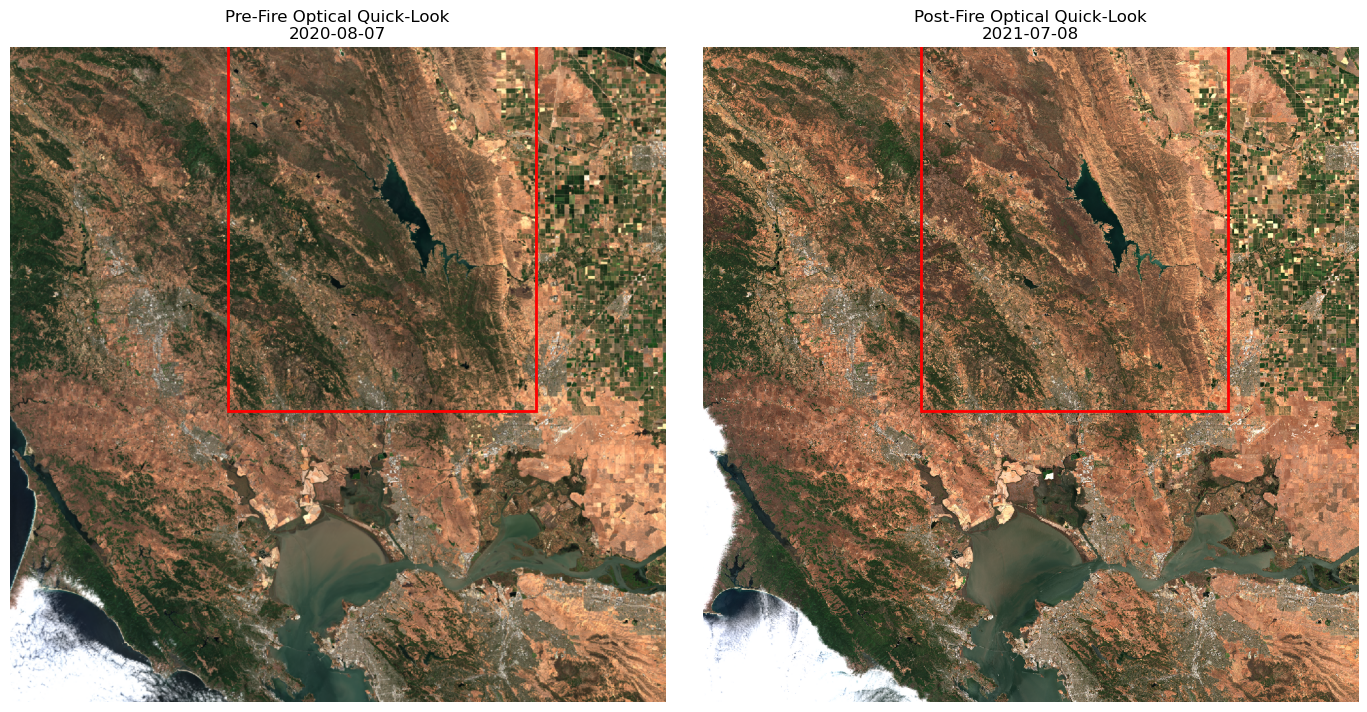

In [16]:
import io
import matplotlib.patches as patches

def inspect_s2_optical_images_with_bounds(candidate, target_bbox):
    """
    Displays a visual preview for Sentinel-2 scenes and overlays a red bounding box representing the fire target zone.
    """
    print("Fetching previews and calculating bounding box overlays...")
    
    _, axes = plt.subplots(1, 2, figsize=(14, 7))
    possible_keys = ['rendered_preview', 'preview', 'thumbnail']
    
    # grab fire bounding box coords: [min_lon, min_lat, max_lon, max_lat]
    f_minx, f_miny, f_maxx, f_maxy = target_bbox
    
    for idx, (period, item_key) in enumerate([('Pre-Fire', 'pre_s2'), ('Post-Fire', 'post_s2')]):
        item = candidate[item_key]
        img_loaded = False
        
        # grab the satellite tile's total footprint coordinates
        t_minx, t_miny, t_maxx, t_maxy = item.bbox
        
        available_keys = [k for k in possible_keys if k in item.assets]
        for key in available_keys:
            try:
                url = item.assets[key].href
                response = requests.get(url, timeout=15)
                
                if response.status_code == 200 and 'image' in response.headers.get('Content-Type', ''):
                    img = Image.open(io.BytesIO(response.content))
                    axes[idx].imshow(img)
                    
                    # convert image size to numpy dimensions
                    img_w, img_h = img.size 
                    
                    # calculate relative position of fire bounds within the tile (0.0 to 1.0)
                    pixel_minx = ((f_minx - t_minx) / (t_maxx - t_minx)) * img_w
                    pixel_maxx = ((f_maxx - t_minx) / (t_maxx - t_minx)) * img_w
                    pixel_miny = (1.0 - (f_maxy - t_miny) / (t_maxy - t_miny)) * img_h
                    pixel_maxy = (1.0 - (f_miny - t_miny) / (t_maxy - t_miny)) * img_h
                    
                    box_width = pixel_maxx - pixel_minx
                    box_height = pixel_maxy - pixel_miny
                    
                    # creat the red outline of the fire
                    rect = patches.Rectangle(
                        (pixel_minx, pixel_miny), 
                        box_width, 
                        box_height, 
                        linewidth=2, 
                        edgecolor='red', 
                        facecolor='none',
                        label='Target Zone'
                    )
                    axes[idx].add_patch(rect)
                    
                    # polish it up 
                    axes[idx].set_title(f"{period} Optical Quick-Look\n{candidate[item_key+'_time'].strftime('%Y-%m-%d')}")
                    axes[idx].axis('off')
                    img_loaded = True
                    break
            except Exception as e:
                continue
                
        if not img_loaded:
            axes[idx].text(0.5, 0.5, "Failed to load preview images", ha='center', va='center')
            axes[idx].axis('off')
            
    plt.tight_layout()
    plt.show()

# Run the updated overlay function
inspect_s2_optical_images_with_bounds(current_choice, stac_boundary_box)

### Download full Sentinel scenes

We will retrieve the raw SAFE files from the [Copernicus Data Space Portal](https://dataspace.copernicus.eu/) and then send them straight to our S3 blob.

First step is to extract the tile ID and platform from each Sentinel-2 STAC item and query the CSDE cloud database to locate the matching data package.

In [17]:
def pinpoint_s2_scene_on_cdse(stac_item):
    """
    Finds a scene on CDSE by extracting metadata properties directly
    from the STAC item object to avoid string splitting errors.
    """
    # pull properties natively from the STAC item metadata and standardize platform name
    tile_id = stac_item.properties.get("s2:mgrs_tile")     
    platform = stac_item.properties.get("platform")        
    platform_code = "S2A" if "A" in platform else "S2B"
    
    # extract the exact acquisition date and format as YYYY-MM-DD
    acq_time = stac_item.datetime
    date_str = acq_time.strftime("%Y-%m-%d")
    
    # construct the structural CDSE query using the clean parameters
    query_url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter=Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/OData.CSC.StringAttribute/any(att:att/Name eq 'tileId' and att/att/Value eq '{tile_id}') and "
        f"ContentDate/Start ge {date_str}T00:00:00.000Z and "
        f"ContentDate/Start le {date_str}T23:59:59.999Z"
    )
    
    print(f"Querying CDSE catalog for tile {tile_id} ({platform_code}) at the date {date_str}...")
    response = requests.get(query_url, timeout=15).json()

    raw_matches = response.get('value', [])
    if not raw_matches:
        print("No matches found in the raw query. Double check your date boundaries or tile extraction.")
        return None
    
    # filter list comp to only accept official Sentinel Level-2A products
    l2a_matches = [prod for prod in raw_matches if "_MSIL2A_" in prod['Name']]
    
    if not l2a_matches:
        print("Matches were found, but none of them passed the Level-2A (MSIL2A) validation filter.")
        return None
        
    for idx, product in enumerate(l2a_matches):
        print(f"[Match {idx+1}] Located Verified L2A Scene on Copernicus Servers:")
        print(f"Official Name: {product['Name']}")
        print(f"CDSE UUID: {product['Id']}")
        print(f"Data Size: {product['ContentLength'] / (1024**2):.2f} MB")
        
    # Return the first matching L2A product payload
    return l2a_matches[0]


In [18]:
print("Locating Sentinel-2 pre fire scene.")
s2_pre_product = pinpoint_s2_scene_on_cdse(final_pre_s2_item)
print("Locating Sentinel-2 post fire scene.")
s2_post_product = pinpoint_s2_scene_on_cdse(final_post_s2_item)

Locating Sentinel-2 pre fire scene.
Querying CDSE catalog for tile 10SEH (S2B) at the date 2020-08-07...
[Match 1] Located Verified L2A Scene on Copernicus Servers:
Official Name: S2B_MSIL2A_20200807T184919_N0500_R113_T10SEH_20230421T033538.SAFE
CDSE UUID: 0a48cdae-3533-493b-8433-e43241a651a4
Data Size: 1155.49 MB
Locating Sentinel-2 post fire scene.
Querying CDSE catalog for tile 10SEH (S2A) at the date 2021-07-08...
[Match 1] Located Verified L2A Scene on Copernicus Servers:
Official Name: S2A_MSIL2A_20210708T184921_N0500_R113_T10SEH_20230124T022549.SAFE
CDSE UUID: 7e4b0900-ed2a-4b55-8e99-c0682e14bd91
Data Size: 1140.64 MB


Next is to use string IDs to match Sentinel-1 STAC item and to the SAFE folder living somewhere in the CSDE cloud database, then retrieve and download the matching data package.

In [19]:
def pinpoint_s1_scene_on_cdse(stac_item):
    """
    Finds the exact matching Sentinel-1 GRD COG scene on CDSE by extraction
    of the immutable product identifier fingerprint from the STAC ID.
    """
    stac_id = stac_item.id
    
    # extract the core unique string segment of the scene
    id_parts = stac_id.split('_')
    core_fingerprint = "_".join(id_parts[:8]) 
    
    # query CDSE catalog directly for any COG package containing this exact string sequence
    query_url = (
        "https://catalogue.dataspace.copernicus.eu/odata/v1/Products?"
        f"$filter=Collection/Name eq 'SENTINEL-1' and "
        f"contains(Name, '{core_fingerprint}') and "
        f"contains(Name, '_COG')"
    )
    
    print(f"Querying CDSE using unique identifier track: {core_fingerprint}...")
    response = requests.get(query_url, timeout=15).json()
    
    valid_matches = response.get('value', [])
    if not valid_matches:
        print("Direct fingerprint match failed. Ensure the source STAC ID is valid.")
        return None
        
    chosen_product = valid_matches[0]
    print("Verified S1 Scene Isolated Successfully:")
    print(f"Name: {chosen_product['Name']}")
    print(f"UUID: {chosen_product['Id']}")
    print(f"Size: {chosen_product['ContentLength'] / (1024**2):.2f} MB")
    
    return chosen_product

In [20]:
print("Locating Sentinel-1 pre fire scene.")
s1_pre_product = pinpoint_s1_scene_on_cdse(final_pre_s1_item)
print("Locating Sentinel-1 post fire scene.")
s1_post_product = pinpoint_s1_scene_on_cdse(final_post_s1_item)

Locating Sentinel-1 pre fire scene.
Querying CDSE using unique identifier track: S1A_IW_GRDH_1SDV_20200806T141548_20200806T141613_033787_03EAB1...
Verified S1 Scene Isolated Successfully:
Name: S1A_IW_GRDH_1SDV_20200806T141548_20200806T141613_033787_03EAB1_CBFE_COG.SAFE
UUID: 3518fb0c-f593-492c-a755-08e6352d5884
Size: 1104.67 MB
Locating Sentinel-1 post fire scene.
Querying CDSE using unique identifier track: S1A_IW_GRDH_1SDV_20210708T141552_20210708T141617_038687_0490B8...
Verified S1 Scene Isolated Successfully:
Name: S1A_IW_GRDH_1SDV_20210708T141552_20210708T141617_038687_0490B8_1B85_COG.SAFE
UUID: 7c4d5b2a-38ad-4010-83d1-45b60f7b9d47
Size: 1111.01 MB


### Download ERA5 Data
Download the ERA5 temporal data from the Copernicus Climate Data Store

In [21]:
import math
from shapely.geometry import shape

def calculate_master_era5_area(cdse_products):
    """
    Takes a list of CDSE product dictionaries, extracts their geographic footprints,
    and returns a single unified floor/ceil ERA5 area envelope [North, West, South, East].
    """
    all_min_lon = []
    all_max_lon = []
    all_min_lat = []
    all_max_lat = []
    
    for product in cdse_products:
        if isinstance(product, dict) and 'GeoFootprint' in product:
            # Parse the GeoJSON footprint directly into a Shapely geometry
            geom_bounds = shape(product['GeoFootprint']).bounds
            
            all_min_lon.append(geom_bounds[0])
            all_min_lat.append(geom_bounds[1])
            all_max_lon.append(geom_bounds[2])
            all_max_lat.append(geom_bounds[3])
        else:
            raise ValueError("Invalid input: Expected a CDSE product dictionary containing 'GeoFootprint'.")
            
    # Calculate the absolute outer bounding thresholds matching ERA5 standards
    master_era5_area = [
        math.ceil(max(all_max_lat)),   # North
        math.floor(min(all_min_lon)),  # West
        math.floor(min(all_min_lat)),  # South
        math.ceil(max(all_max_lon))    # East
    ]

    print(f"Spatial Envelope Rounded Coordinates [N, W, S, E]: {master_era5_area}")
    
    return master_era5_area

In [22]:
import cdsapi

def download_antecedent_era5(era5_area, output_dir=None):
    """
    Calculates the exact 30 days prior to ignition, determines the combined 
    outer bounding box envelope, and requests unarchived GRIB data from ECMWF.
    """
    if output_dir is None:
        output_dir = os.path.abspath(os.path.join(os.getcwd(), "..", f"{fire_name}_fire/grib_folder"))
    os.makedirs(output_dir, exist_ok=True)
    
    # calculate time windows based on Sentinel-2 acquisition (Pre-fire scene)
    ignition_datetime = pd.to_datetime(ignition_date)
    start_date = ignition_datetime - timedelta(days=30)
    
    print(f"True Ignition Date: {ignition_datetime.strftime('%Y-%m-%d')}")
    print(f"30-Day Data Collection Window: {start_date.strftime('%Y-%m-%d')} to {ignition_datetime.strftime('%Y-%m-%d')}")
    
    # generate list of target days, months, and years
    curr_year = ignition_datetime.strftime("%Y")
    curr_month = ignition_datetime.strftime("%m")
    
    # calculate the previous month (with carryover)
    prev_month_date = ignition_datetime - pd.DateOffset(months=1)
    prev_month = prev_month_date.strftime("%m")
    prev_month_year = prev_month_date.strftime("%Y")
    
    years_list = list(set([curr_year, prev_month_year]))
    months_list = [prev_month, curr_month]
    
    # hardcode all possible calendar days to pull full month arrays
    days_list = [f"{d:02d}" for d in range(1, 32)]
    
    # construct the ECMWF API payload Request
    c = cdsapi.Client()
    
    output_filename = os.path.join(output_dir, f"era5_antecedent_{ignition_datetime.strftime('%Y%m%d')}.grib")
    
    request_params = {
        'product_type': 'reanalysis',
        'format': 'grib',  # download format unarchived direct GRIB payload
        'variable': [
            '10m_u_component_of_wind', 
            '10m_v_component_of_wind', 
            '2m_dewpoint_temperature',
            '2m_temperature', 
            'total_precipitation'
        ],
        'year': list(years_list),
        'month': list(months_list),
        'day': sorted(list(days_list)),
        'time': [
            '00:00', '01:00', '02:00', '03:00', '04:00', '05:00',
            '06:00', '07:00', '08:00', '09:00', '10:00', '11:00',
            '12:00', '13:00', '14:00', '15:00', '16:00', '17:00',
            '18:00', '19:00', '20:00', '21:00', '22:00', '23:00'
        ],
        'area': era5_area,
    }
    
    print("Transmitting download request token to Copernicus Climate Data Store...")
    c.retrieve('reanalysis-era5-single-levels', request_params, output_filename)
    print(f"ERA5 Antecedent GRIB array saved: {output_filename}\n")
    
    return output_filename 

In [26]:
active_products = [s1_pre_product, s1_post_product, s2_pre_product, s2_post_product]
master_era5_area = calculate_master_era5_area(active_products)
era5_file_path = download_antecedent_era5(master_era5_area)

Spatial Envelope Rounded Coordinates [N, W, S, E]: [41, -125, 37, -121]
True Ignition Date: 2020-08-17
30-Day Data Collection Window: 2020-07-18 to 2020-08-17
Transmitting download request token to Copernicus Climate Data Store...


2026-06-04 12:01:29,831 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-06-04 12:01:29,831 INFO Request ID is a9cc09fb-319b-4ae3-b936-0fb31780e1b6
2026-06-04 12:01:29,974 INFO status has been updated to accepted
2026-06-04 12:03:32,448 INFO status has been updated to successful


3283c490f9e620624ca1bc579dcb37a3.grib:   0%|          | 0.00/4.87M [00:00<?, ?B/s]

ERA5 Antecedent GRIB array saved: /Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib



In [27]:
# investigate ERA5 grib to ensure it is correct
import sys
sys.path.append('..')

from data.loaders import load_era5_vars
era5_processed_data = load_era5_vars(era5_file_path)


Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
Ignoring index file '/Users/asankoh/WildfirePrediction/HENNESSEY_fire/grib_folder/era5_antecedent_20200817.grib.5b7b6.idx' older than GRIB file
/Users/asankoh/opt/anaconda3/envs/wildfire-pred/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future versi

In [28]:
# convert the Xarray coordinate arrays into standard pandas datetime lists
time_coords = era5_processed_data['u10'].coords['time'].values
time_series = pd.to_datetime(time_coords)

start_time = time_series.min()
end_time = time_series.max()
total_days = (end_time - start_time).days + 1

# extract Geographic Coordinates
lat_coords = era5_processed_data['u10'].coords['latitude'].values
lon_coords = era5_processed_data['u10'].coords['longitude'].values

print("ERA-5 Time Statistics")
print(f"Total Hourly Timesteps: {len(time_series)}")
print(f"Data Starts On:         {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Data Ends On:           {end_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Calendar Range: {total_days} days")

print("ERA-5 Geographic Statistics")
print(f"Latitude Range:  {lat_coords.min()}°N to {lat_coords.max()}°N  (Resolution: 0.25° grid cells)")
print(f"Longitude Range: {lon_coords.min()}°E to {lon_coords.max()}°E")
print(f"Grid Matrix Size: {len(lat_coords)} rows x {len(lon_coords)} columns ({len(lat_coords) * len(lon_coords)} total spatial cells)")

print("ERA-5 Geographic Statistics")
for key, item in era5_processed_data.items():
    print(f"Variable: {key} ---------")
    print(f"Item: {item}")

ERA-5 Time Statistics
Total Hourly Timesteps: 1488
Data Starts On:         2020-07-01 00:00:00
Data Ends On:           2020-08-31 23:00:00
Calendar Range: 62 days
ERA-5 Geographic Statistics
Latitude Range:  37.0°N to 41.0°N  (Resolution: 0.25° grid cells)
Longitude Range: -125.0°E to -121.0°E
Grid Matrix Size: 17 rows x 17 columns (289 total spatial cells)
ERA-5 Geographic Statistics
Variable: u10 ---------
Item: <xarray.DataArray 'u10' (time: 1488, latitude: 17, longitude: 17)> Size: 2MB
[430032 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 12kB 2020-07-01 ... 2020-08-31T23:00:00
    valid_time  (time) datetime64[ns] 12kB 2020-07-01 ... 2020-08-31T23:00:00
  * latitude    (latitude) float64 136B 41.0 40.75 40.5 ... 37.5 37.25 37.0
  * longitude   (longitude) float64 136B -125.0 -124.8 -124.5 ... -121.2 -121.0
    number      int64 8B 0
    step        timedelta64[ns] 8B 00:00:00
    surface     float64 8B 0.0
Attributes: (12/31)
    GRIB_paramId:      

### Final Checks 
Confirm the all dates/times and coordinates are correct for each of the file sources.

In [29]:
# geographical checks 
from shapely.geometry import shape 

print("Running Geographic Validation Checks...")

# check S1 pre is within the ERA5 geographic snapshot 
s1_pre_footprint_geom = shape(s1_pre_product['GeoFootprint'])
s1_pre_bounds = s1_pre_footprint_geom.bounds 
s1_pre_min_long = s1_pre_bounds[0] 
s1_pre_max_long = s1_pre_bounds[2]
s1_pre_min_lat = s1_pre_bounds[1]
s1_pre_max_lat = s1_pre_bounds[3]

if lat_coords.min() > s1_pre_min_lat or lon_coords.min() > s1_pre_min_long:
    raise ValueError("S1 pre is located outside of the ERA5 boundary box.")
if lat_coords.max() < s1_pre_max_lat or lon_coords.max() < s1_pre_max_long:
    raise ValueError("S1 pre is located outside of the ERA5 boundary box.")

print("-> S1 pre is located within the ERA5 boundary box.")

# check S1 post is within the ERA5 geographic snapshot 
s1_post_footprint_geom = shape(s1_post_product['GeoFootprint'])
s1_post_bounds = s1_post_footprint_geom.bounds 
s1_post_min_long = s1_post_bounds[0] 
s1_post_max_long = s1_post_bounds[2]
s1_post_min_lat = s1_post_bounds[1]
s1_post_max_lat = s1_post_bounds[3]

if lat_coords.min() > s1_post_min_lat or lon_coords.min() > s1_post_min_long:
    raise ValueError("S1 post is located outside of the ERA5 boundary box.")
if lat_coords.max() < s1_post_max_lat or lon_coords.max() < s1_post_max_long:
    raise ValueError("S1 post is located outside of the ERA5 boundary box.")

print("-> S1 post is located within the ERA5 boundary box.")

# check S2 pre is within the ERA5 geographic snapshot 
s2_pre_footprint_geom = shape(s2_pre_product['GeoFootprint'])
s2_pre_bounds = s2_pre_footprint_geom.bounds 
s2_pre_min_long = s2_pre_bounds[0] 
s2_pre_max_long = s2_pre_bounds[2]
s2_pre_min_lat = s2_pre_bounds[1]
s2_pre_max_lat = s2_pre_bounds[3]

if lat_coords.min() > s2_pre_min_lat or lon_coords.min() > s2_pre_min_long:
    raise ValueError("S2 pre is located outside of the ERA5 boundary box.")
if lat_coords.max() < s2_pre_max_lat or lon_coords.max() < s2_pre_max_long:
    raise ValueError("S2 pre is located outside of the ERA5 boundary box.")

print("-> S2 pre is located within the ERA5 boundary box.")

# check S1 post is within the ERA5 geographic snapshot 
s2_post_footprint_geom = shape(s2_post_product['GeoFootprint'])
s2_post_bounds = s2_post_footprint_geom.bounds 
s2_post_min_long = s2_post_bounds[0] 
s2_post_max_long = s2_post_bounds[2]
s2_post_min_lat = s2_post_bounds[1]
s2_post_max_lat = s2_post_bounds[3]

if lat_coords.min() > s2_post_min_lat or lon_coords.min() > s2_post_min_long:
    raise ValueError("S2 post is located outside of the ERA5 boundary box.")
if lat_coords.max() < s2_post_max_lat or lon_coords.max() < s2_post_max_long:
    raise ValueError("S2 post is located outside of the ERA5 boundary box.")

print("-> S2 post is located within the ERA5 boundary box.")

Running Geographic Validation Checks...
-> S1 pre is located within the ERA5 boundary box.
-> S1 post is located within the ERA5 boundary box.
-> S2 pre is located within the ERA5 boundary box.
-> S2 post is located within the ERA5 boundary box.


In [30]:
# temporal checks

def run_temporal_pipeline_checks(
    s1_pre_product, s1_post_product, 
    s2_pre_product, s2_post_product, 
    ignition_date, optimal_post_date, time_series
):
    print("Running Temporal Pipeline Validation Checks...\n")
    
    # helper function that parses CDSE ISO timestamps to pandas datetime objects ---
    def parse_cdse_time(product):
        raw_str = product['ContentDate']['Start']
        # strip trailing 'Z' if present and convert to standard naive timestamp
        return pd.to_datetime(raw_str.replace('Z', ''))

    t_s1_pre = parse_cdse_time(s1_pre_product)
    t_s1_post = parse_cdse_time(s1_post_product)
    t_s2_pre = parse_cdse_time(s2_pre_product)
    t_s2_post = parse_cdse_time(s2_post_product)
    
    t_ignition = pd.to_datetime(ignition_date)
    t_optimal_post = pd.to_datetime(optimal_post_date)
    
    
    # confirm that the pre S1 and S2 scenes are <36 hours apart
    pre_delta_hours = abs((t_s1_pre - t_s2_pre).total_seconds()) / 3600.0
    if pre_delta_hours >= 36:
        raise ValueError(f"ERROR: Pre-fire S1 and S2 scenes are {pre_delta_hours:.1f} hours apart (Limit: 36h).")
    print(f"-> Check 1 Passed: Pre-fire S1/S2 are only {pre_delta_hours:.1f} hours apart.")

    # confirm that the post S1 and S2 scenes are <36 hours apart
    post_delta_hours = abs((t_s1_post - t_s2_post).total_seconds()) / 3600.0
    if post_delta_hours >= 36:
        raise ValueError(f"ERROR: Post-fire S1 and S2 scenes are {post_delta_hours:.1f} hours apart (Limit: 36h).")
    print(f"-> Check 2 Passed: Post-fire S1/S2 are only {post_delta_hours:.1f} hours apart.")
    
    # confirming both pre scenes are within the 20 day window leading up to ignition
    pre_window_start = t_ignition - pd.Timedelta(days=20)
    
    # Condition: must be after (or equal to) 20 days ago, and strictly before the ignition day
    if not (pre_window_start <= t_s1_pre < t_ignition) or not (pre_window_start <= t_s2_pre < t_ignition):
        raise ValueError(
            f"ERROR: Pre-scenes fall outside the 20-day window leading to ignition.\n"
            f"   Allowed Window: {pre_window_start.strftime('%Y-%m-%d')} to {t_ignition.strftime('%Y-%m-%d')}\n"
            f"   Actual S1 Pre:  {t_s1_pre.strftime('%Y-%m-%d')}\n"
            f"   Actual S2 Pre:  {t_s2_pre.strftime('%Y-%m-%d')}"
        )
    print("-> Check 3 Passed: Both pre-fire satellite scenes sit inside the 20-day pre-ignition runway.")

    # confirming both post scenes are within 20 days around optimal post date
    post_window_start = t_optimal_post - pd.Timedelta(days=10)
    post_window_end = t_optimal_post + pd.Timedelta(days=10)
    
    if not (post_window_start <= t_s1_post <= post_window_end) or not (post_window_start <= t_s2_post <= post_window_end):
        raise ValueError(
            f"CRITICAL: Post-scenes fall outside the 20-day envelope centered on the optimal date ID.\n"
            f"   Allowed Envelope: {post_window_start.strftime('%Y-%m-%d')} to {post_window_end.strftime('%Y-%m-%d')}\n"
            f"   Actual S1 Post:   {t_s1_post.strftime('%Y-%m-%d')}\n"
            f"   Actual S2 Post:   {t_s2_post.strftime('%Y-%m-%d')}"
        )
    print("-> Check 4 Passed: Both post-fire satellite scenes sit inside the 20-day optimal post envelope.")

    # Confirming the ERA5 monthly data covers the month of and before ignition
    target_months = {t_ignition.strftime("%Y-%m"), (t_ignition - pd.DateOffset(months=1)).strftime("%Y-%m")}
    actual_months = set(time_series.strftime("%Y-%m"))
    
    if not target_months.issubset(actual_months):
        raise ValueError(
            f"ERROR: ERA5 block data is missing required full calendar months.\n"
            f"   Required Months: {target_months}\n"
            f"   GRIB File Months: {actual_months}"
        )
    print(f"-> Check 5 Passed: ERA5 array safely contains complete blocks for months: {actual_months}")

# Execute the matrix check
run_temporal_pipeline_checks(
    s1_pre_product, s1_post_product, 
    s2_pre_product, s2_post_product, 
    ignition_date, optimal_post_date, time_series
)

Running Temporal Pipeline Validation Checks...

-> Check 1 Passed: Pre-fire S1/S2 are only 28.6 hours apart.
-> Check 2 Passed: Post-fire S1/S2 are only 4.6 hours apart.
-> Check 3 Passed: Both pre-fire satellite scenes sit inside the 20-day pre-ignition runway.
-> Check 4 Passed: Both post-fire satellite scenes sit inside the 20-day optimal post envelope.
-> Check 5 Passed: ERA5 array safely contains complete blocks for months: {'2020-07', '2020-08'}


# Send Sentinel Products and ERA5 Grib to S3 Bucket

In order to skip saving large Sentinel SAFE files onto my local, I will send them directly to an S3 bucket that will hold my entire wildfire prediction dataset. The ERA5 data must be sent from local since I need to download the GRIB folder and verify myself that the timesteps, geographic coordinates, and downloaded variables are correct.

In [31]:
def format_coordinate_strings(stac):
    """
    Translates the fire's MTBS boundary box [min_long, min_lat, max_long, max_lat]
    into a unified coordinate tracking string. 
    """
    min_long, min_lat, max_long, max_lat = stac

    # calculate the centroid of the fire 
    center_lat = (min_lat + max_lat) / 2.0
    center_lon = (min_long + max_long) / 2.0

    lat_suffix = 'N' if center_lat >= 0 else 'S'
    lon_suffix = 'E' if center_lon >= 0 else 'W'

    # round to the nearest integer matching 
    lat_val = abs(int(round(center_lat)))
    lon_val = abs(int(round(center_lon)))

    return f"{lat_val}{lat_suffix}{lon_val}{lon_suffix}"

In [32]:
def get_cdse_token():
    """
    Generate and retrieve an access token from the Copernicus Dataspace Ecosystem.
    """
    auth_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    payload = {
        'client_id': 'cdse-public',
        'grant_type': 'password',
        'username': os.getenv("CDSE_EMAIL"),
        'password': os.getenv("CDSE_PASSWORD")
    }
    
    response = requests.post(auth_url, data=payload)
    response.raise_for_status()
    return response.json()['access_token']

In [33]:
import json
import os

def create_and_upload_metadata(
    s3_client,
    state,
    fire_name,
    mtbs_event_id,
    mtbs_post_id,
    spatial_bounds,
    uploaded_files,
    spatial_coverage,  
    bucket_name,
    bucket_owner_id,
):
    """Creates a local metadata.json file containing filename mappings

    and explicit spatial coverage constraints, then uploads to S3.
    """
    # Force ERA5 tracking metrics to 100% boundary containment
    spatial_coverage["ERA5"] = 100.0

    metadata = {
        "event_id": mtbs_event_id,
        "fire_name": fire_name,
        "state": state,
        "mtbs_post_id": mtbs_post_id,
        "spatial_bounds": spatial_bounds,
        "spatial_coverage": spatial_coverage,  
        "contents": uploaded_files,
    }

    local_filename = f"{fire_name}_metadata.json"
    s3_key = f"{state}/{fire_name}/metadata.json"

    try:
        with open(local_filename, "w") as f:
            json.dump(metadata, f, indent=4)

        extra_args = {
            "ContentType": "application/json",
            "ExpectedBucketOwner": bucket_owner_id,
        }

        print(f"Syncing metadata to s3://{bucket_name}/{s3_key}...")

        s3_client.upload_file(
            Filename=local_filename,
            Bucket=bucket_name,
            Key=s3_key,
            ExtraArgs=extra_args,
        )
        print(f" Metadata successfully synchronized for {fire_name}!")

    except Exception as e:
        print(f"Failed to process metadata for {fire_name}. Error: {e}")

    finally:
        if os.path.exists(local_filename):
            os.remove(local_filename)

In [34]:
import boto3
from boto3.s3.transfer import TransferConfig
from tqdm import tqdm

class ProgressPercentage(object):
    """Tracks upload progress callback for boto3."""
    def __init__(self, filename, total_size):
        self._filename = filename
        self._size = total_size
        self._pbar = tqdm(
            desc=f"📤 Uploading {filename}",
            total=total_size,
            unit='B',
            unit_scale=True,
            unit_divisor=1024
        )

    def __call__(self, bytes_amount):
        self._pbar.update(bytes_amount)
        
    def close(self):
        self._pbar.close()

def upload_to_s3(
        cdse_products_dict, 
        local_era5_path,
        state_code,
        fire_name,
        bucket_name="wildfire-scenes-s3-202802195212-us-east-1-an"
):
    s3_client = boto3.client('s3')
    coord_str = format_coordinate_strings(stac_boundary_box)

    # dynamically track uploaded assets
    uploaded_assets = {}

    s3_folder_prefix = f"{state_code.upper()}/{fire_name.upper()}_fire/"
    print(f"Starting cloud sync to s3 folder: s3://{bucket_name}/{s3_folder_prefix}")

    # stream CDSE Sentinel products directly to S3
    for key, product in cdse_products_dict.items():
        source, phase = key.split('_')

        # parse timestamp from CDSE metadata
        raw_time = product['ContentDate']['Start'].replace('Z', '')
        timestamp_str = pd.to_datetime(raw_time).strftime("%Y%m%d")

        # generate name: [Source]_[StateCode]_[Coordinates]_[timestamp]_[phase].SAFE
        s3_filename = f"{source}_{state_code.upper()}_{coord_str}_{timestamp_str}_{phase}.SAFE"
        s3_key = f"{s3_folder_prefix}{s3_filename}"

        # upload massive chunks at a time and multi-thread 
        config = TransferConfig(
            multipart_threshold=1024 * 1024 * 25,  
            multipart_chunksize=1024 * 1024 * 15,  
            max_concurrency=10,                    
            use_threads=True
        )

        uploaded_assets[f"{source}_{phase}"] = s3_filename

        # CDSE direct download data URL string
        # adjust URL endpoint token mapping depending on your pinpoint function return payload
        s3_path = product.get('S3Path')
        
        # safely resolve the HTTP endpoint
        if s3_path:
            if s3_path.startswith('/eodata/'):
                download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product['Id']})/$value"
            else:
                download_url = s3_path
        else:
            download_url = f"https://zipper.dataspace.copernicus.eu/odata/v1/Products({product['Id']})/$value"
        print(f"Streaming {source} ({phase}) to S3 Key: {s3_key}...")

        # request stream session connection from CDSE zipper endpoint
        # add your CDSE authorization headers if your pinpoint setup requires them here

        access_token = get_cdse_token()
        headers = {
            'Authorization': f'Bearer {access_token}'
        } 
        with requests.get(download_url, headers=headers, stream=True, timeout=60) as response:
            response.raise_for_status()

            # get total file size from CDSE headers if available
            total_size = int(response.headers.get('content-length', 0))
            progress = ProgressPercentage(s3_filename, total_size)

            extra_args = {
                'ExpectedBucketOwner': '202802195212' # Replace with your 12-digit AWS Account ID
            }

            s3_client.upload_fileobj(
                Fileobj=response.raw, 
                Bucket=bucket_name, 
                Key=s3_key,
                ExtraArgs=extra_args,
                Callback=progress, 
                Config=config
            )
            progress.close()
        
        print(f" Stream Complete: {s3_filename}")

    
    if os.path.exists(local_era5_path):
        era5_timestamp = local_era5_path.split('_')[-1].split('.')[0] 
        era5_filename = f"ERA5_{state_code.upper()}_{coord_str}_{era5_timestamp}.grib"
        era5_s3_key = f"{s3_folder_prefix}{era5_filename}"

        uploaded_assets["ERA5"] = era5_filename
        
        print(f"Uploading locally validated ERA5 array to S3 Key: {era5_s3_key}...")

        # get total file size and initialize the tracker
        file_size = os.path.getsize(local_era5_path)
        progress = ProgressPercentage(era5_filename, file_size)

        extra_args = {
            'ExpectedBucketOwner': '202802195212' 
        }

        s3_client.upload_file(
            Filename=local_era5_path, 
            Bucket=bucket_name, 
            Key=era5_s3_key,
            ExtraArgs=extra_args,
            Callback=progress
        )
        progress.close()
    
        create_and_upload_metadata(
            s3_client=s3_client,
            state=state_code.upper(),
            fire_name=f"{fire_name.upper()}_fire",
            mtbs_event_id=fire_id_string,          
            mtbs_post_id=post_id_string,
            spatial_bounds=stac_boundary_box,
            spatial_coverage=coverages,
            uploaded_files=uploaded_assets,       
            bucket_name=bucket_name,              
            bucket_owner_id="202802195212"        
        )
    
        print(f"Local Upload Complete: {era5_filename}")
    else:
        print(f"Warning: Local ERA5 file not found at {local_era5_path}, skipping.")

    print(f"S3 Storage Bundle Sync Complete for {fire_name.upper()} Fire dataset!")

In [ ]:
# Group your validated products with explicit labels
validated_cdse_matrix = {
    "S1_pre": s1_pre_product,
    "S1_post": s1_post_product,
    "S2_pre": s2_pre_product,
    "S2_post": s2_post_product
}

# Kick off streaming execution
upload_to_s3(
    cdse_products_dict=validated_cdse_matrix,
    local_era5_path=era5_file_path, 
    state_code="CA",
    fire_name=fire_name                  
)

Starting cloud sync to s3 folder: s3://wildfire-scenes-s3-202802195212-us-east-1-an/CA/HENNESSEY_fire/
Streaming S1 (pre) to S3 Key: CA/HENNESSEY_fire/S1_CA_39N122W_20200806_pre.SAFE...


📤 Uploading S1_CA_39N122W_20200806_pre.SAFE: 100%|██████████| 1.08G/1.08G [11:01<00:00, 1.75MB/s]  


 Stream Complete: S1_CA_39N122W_20200806_pre.SAFE
Streaming S1 (post) to S3 Key: CA/HENNESSEY_fire/S1_CA_39N122W_20210708_post.SAFE...


📤 Uploading S1_CA_39N122W_20210708_post.SAFE: 100%|██████████| 1.08G/1.08G [16:58<00:00, 1.14MB/s]  


 Stream Complete: S1_CA_39N122W_20210708_post.SAFE
Streaming S2 (pre) to S3 Key: CA/HENNESSEY_fire/S2_CA_39N122W_20200807_pre.SAFE...


📤 Uploading S2_CA_39N122W_20200807_pre.SAFE: 100%|██████████| 1.13G/1.13G [04:42<00:00, 4.29MB/s] 


 Stream Complete: S2_CA_39N122W_20200807_pre.SAFE
Streaming S2 (post) to S3 Key: CA/HENNESSEY_fire/S2_CA_39N122W_20210708_post.SAFE...


📤 Uploading S2_CA_39N122W_20210708_post.SAFE:  11%|█         | 120M/1.11G [00:51<04:18, 4.15MB/s]  